## 1. Imports and Configuration

We import the core libraries used throughout this notebook:
- **pandas / numpy** — data manipulation and numerical computation
- **matplotlib / seaborn** — visualisation
- **XGBoost** — our primary forecasting model
- **sklearn.metrics** — RMSE and MAE computation
- **shap** — model interpretability via Shapley values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shap
import seaborn as sns

from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(" All libraries imported successfully.")

 All libraries imported successfully.


## 2. Load Dataset

We load the preprocessed remittance dataset covering **2012–2025**, which has already been cleaned and merged with macroeconomic covariates (exchange rate, oil price, DOFE departure data). The index is set to the `date` column and sorted chronologically to ensure correct time ordering before any operations.

In [2]:

df = pd.read_csv( r"E:/2ndYear2ndSemester/Project(DSMA299)/remittance-forecasting/output/remittance_2012_2025_model_ready.csv", parse_dates=['date'])
df = df.set_index('date')
df = df.sort_index()  # Make sure dates are in ascending order

print(f"Shape: {df.shape}  (rows × columns)")
print(f"Date range: {df.index.min().strftime('%b %Y')} → {df.index.max().strftime('%b %Y')}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Shape: (151, 8)  (rows × columns)
Date range: May 2013 → Nov 2025

Column names:
['remittance', 'exchange_rate', 'oil_price', 'dofe_departures', 'dofe_lag3', 'dofe_lag6', 'dofe_lag9', 'covid_shock']

First 5 rows:


,remittance,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
date,,,,,,,,
2013-05-01,40065.5,87.91,99.366633,54818.0,51516.0,34990.0,45417.0,0
2013-06-01,45815.2,93.02,99.742667,58937.0,55439.0,54304.0,38297.0,0
2013-07-01,46119.4,95.30,105.257905,59707.0,58054.0,57951.0,47067.0,0
2013-08-01,41867.3,98.26,108.157636,54134.0,54818.0,51516.0,34990.0,0
2013-09-01,46168.5,101.59,108.757730,32607.0,58937.0,55439.0,54304.0,0


## 3. Exploratory Summary Statistics

Before modelling, we inspect the distributional properties of all variables — mean, standard deviation, min/max, and quartiles. This helps us identify potential outliers, scaling issues, or structural breaks (e.g. the COVID-19 shock period) that may affect model performance.

In [3]:
print("Summary Statistics:")
df.describe().round(2)

Summary Statistics:


,remittance,exchange_rate,oil_price,dofe_departures,dofe_lag3,dofe_lag6,dofe_lag9,covid_shock
count,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00
mean,80975.40,115.59,69.51,51846.31,51576.83,51085.40,50491.79,0.06
std,33820.36,13.44,20.96,18565.51,18415.08,18186.35,17930.49,0.24
min,34516.81,87.91,21.04,0.00,0.00,0.00,0.00,0.00
25%,55128.58,103.81,53.60,45548.00,45548.00,44751.00,44008.50,0.00
50%,72418.96,114.30,68.20,54818.00,54702.00,54337.00,54090.00,0.00
75%,100180.83,128.78,82.26,64644.50,63969.00,62978.00,61928.50,0.00
max,201230.00,141.67,116.80,84226.00,84226.00,84226.00,84226.00,1.00


## 4. Feature Engineering

Raw remittance data alone is insufficient for forecasting. We construct the following features:

**Lag features** — capture autocorrelation by giving the model access to past remittance values:
- `remittance_lag1` → value from 1 month ago
- `remittance_lag2` → 2 months ago
- `remittance_lag3` → 3 months ago
- `remittance_lag6` → 6 months ago

**Time features:**
- `time_index` → integer counter (0, 1, 2 ...) representing global trend
- `month` → month of year (1–12) capturing seasonality

**Target variables** — we shift remittance values forward to create supervised learning targets:
- `target_1m` → remittance 1 month ahead
- `target_3m` → remittance 3 months ahead
- `target_6m` → remittance 6 months ahead

Rows with any NaN values (introduced by shifting) are dropped before modelling.

In [4]:
# ── 3a. Remittance lag features ───────────────────────────────────────────────
df['remittance_lag1'] = df['remittance'].shift(1)
df['remittance_lag2'] = df['remittance'].shift(2)
df['remittance_lag3'] = df['remittance'].shift(3)
df['remittance_lag6'] = df['remittance'].shift(6)

# ── 3b. Time and seasonality features ────────────────────────────────────────
df['time_index'] = np.arange(len(df))   # 0, 1, 2, ... 150
df['month']      = df.index.month        # 1 = January, 12 = December

# ── 3c. Target variables (future values) ─────────────────────────────────────
df['target_1m'] = df['remittance'].shift(-1)   # 1 month ahead
df['target_3m'] = df['remittance'].shift(-3)   # 3 months ahead
df['target_6m'] = df['remittance'].shift(-6)   # 6 months ahead

# ── Drop rows with NaN in any target ─────────────────────────────────────────
# (The last 6 rows will have NaN in target_6m after the shift)
df_model = df.dropna(subset=['target_1m', 'target_3m', 'target_6m',
                               'remittance_lag1', 'remittance_lag2',
                               'remittance_lag3', 'remittance_lag6'])

print(f"Original rows: {len(df)}")
print(f"After dropping NaN rows: {len(df_model)}")
print(f"Date range after cleaning: {df_model.index.min().strftime('%b %Y')} → {df_model.index.max().strftime('%b %Y')}")
print(f"\nNew columns added:")
new_cols = ['remittance_lag1','remittance_lag2','remittance_lag3','remittance_lag6',
            'time_index','month','target_1m','target_3m','target_6m']
print(df_model[new_cols].head(8).round(1))

Original rows: 151
After dropping NaN rows: 139
Date range after cleaning: Nov 2013 → May 2025

New columns added:
            remittance_lag1  remittance_lag2  remittance_lag3  \
date                                                            
2013-11-01          46998.1          46168.5          41867.3   
2013-12-01          43860.2          46998.1          46168.5   
2014-01-01          42283.1          43860.2          46998.1   
2014-02-01          44446.4          42283.1          43860.2   
2014-03-01          46283.1          44446.4          42283.1   
2014-04-01          44816.5          46283.1          44446.4   
2014-05-01          41075.7          44816.5          46283.1   
2014-06-01          46678.2          41075.7          44816.5   

            remittance_lag6  time_index  month  target_1m  target_3m  \
date                                                                   
2013-11-01          40065.5           6     11    42283.1    46283.1   
2013-12-01        

## 5. Train / Calibration / Test Split

We use a **chronological split** — no shuffling — to respect the temporal structure of the data and avoid data leakage.

The data is divided into three non-overlapping periods:

| Split | Period | Purpose |
|---|---|---|
| **Train** | 2013 → 2022 | Fit the XGBoost models |
| **Calibration** | 2023 | Compute conformal prediction quantiles |
| **Test** | Jan 2024 → Nov 2025 | Final out-of-sample evaluation |

The calibration set is carved from the last 20% of training data. It is held out during model fitting and used exclusively to compute the conformal quantile — the half-width of our prediction intervals. This ensures the intervals have valid distribution-free coverage guarantees without touching the test set.

In [5]:
FEATURES = [
    'exchange_rate', 'oil_price', 'dofe_departures',
    'dofe_lag3', 'dofe_lag6', 'dofe_lag9',
    'covid_shock', 'month', 'time_index',
    'remittance_lag1', 'remittance_lag2', 'remittance_lag3', 'remittance_lag6'
]

TARGETS = ['target_1m', 'target_3m', 'target_6m']

TRAIN_END = '2023-09-30'
TEST_START = '2023-10-01'

train_full = df_model.loc[:TRAIN_END]
test       = df_model.loc[TEST_START:]

# Calibration split — last 20% of train for conformal prediction
cal_split = int(len(train_full) * 0.80)
cal_train = train_full.iloc[:cal_split]
cal_set   = train_full.iloc[cal_split:]

print(f"Training set:     {train_full.index.min().strftime('%b %Y')} → {train_full.index.max().strftime('%b %Y')}  ({len(train_full)} months)")
print(f"  Cal train:      {cal_train.index.min().strftime('%b %Y')} → {cal_train.index.max().strftime('%b %Y')}  ({len(cal_train)} months)")
print(f"  Cal set:        {cal_set.index.min().strftime('%b %Y')} → {cal_set.index.max().strftime('%b %Y')}  ({len(cal_set)} months)")
print(f"Test set:         {test.index.min().strftime('%b %Y')} → {test.index.max().strftime('%b %Y')}  ({len(test)} months)")

train_ceiling = train_full['remittance'].max()
test_max      = test['remittance'].max()
exceed_count  = (test['remittance'] > train_ceiling).sum()

print(f"\n  Training ceiling:     {train_ceiling:,.0f}")
print(f"  Test max:             {test_max:,.0f}")
print(f"  Months above ceiling: {exceed_count} of {len(test)}")

Training set:     Nov 2013 → Sep 2023  (119 months)
  Cal train:      Nov 2013 → Sep 2021  (95 months)
  Cal set:        Oct 2021 → Sep 2023  (24 months)
Test set:         Oct 2023 → May 2025  (20 months)

  Training ceiling:     116,019
  Test max:             165,300
  Months above ceiling: 16 of 20


## 6. Model Training — XGBoost

We train **three independent XGBoost models**, one per forecasting horizon (1-month, 3-month, 6-month ahead). Key design choices:

- **Log transformation** on the target variable — remittance values are right-skewed and grow over time. Training on `log(target)` stabilises variance and prevents the model from over-weighting large values. Predictions are exponentiated back to the original scale.
- **Same feature set** across all horizons — allows fair comparison of how predictability degrades as the horizon extends.
- **Hyperparameters** — `n_estimators=500`, `learning_rate=0.05`, `max_depth=4` — chosen to balance bias-variance tradeoff on a small monthly dataset (~116 training rows).

In [6]:

   XGB_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

X_train = train_full[FEATURES]
X_test = test[FEATURES]
models = {}
predictions = {}

for target_col in TARGETS:
    y_train = np.log(train_full[target_col])
    y_test = test[target_col]
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(X_train, y_train)
    y_pred = np.exp(model.predict(X_test))
    models[target_col] = model
    predictions[target_col] = y_pred
    print(f" Trained model for {target_col}")

print("\nAll three models trained successfully.")

 Trained model for target_1m
 Trained model for target_3m
 Trained model for target_6m

All three models trained successfully.


## 7. Evaluation — Point Forecasts and Conformal Prediction Intervals

We evaluate each horizon on two levels:

### 7a. Point Forecast Metrics
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **MAE** (Mean Absolute Error) — average magnitude of errors in original units
- **MAPE** (Mean Absolute Percentage Error) — scale-free metric, primary comparison metric with benchmarks

### 7b. Conformal Prediction Intervals
Post-hoc conformal prediction (Vovk et al., 2005) constructs prediction intervals without assumptions about the error distribution:

1. Refit the model on `cal_train` (first 80% of training data)
2. Generate predictions on `cal_set` (calibration period — year 2023)
3. Compute absolute residuals: `|actual - predicted|`
4. Take the empirical `(1 − α)` quantile of those residuals → this is `q_hat`
5. For each test prediction: `interval = [ŷ − q_hat, ŷ + q_hat]`

We use **α = 0.10**, targeting **90% coverage**.

### 7c. Interval Quality Metrics
- **Empirical Coverage** — percentage of test observations that fall inside the interval. Should be close to 90%.
- **Winkler Score** — penalises intervals on both width and misses. Narrower intervals that still cover the true value score lower (better). Formally:

$$W = (U - L) + \frac{2}{\alpha} \cdot \max(0, L - y) + \frac{2}{\alpha} \cdot \max(0, y - U)$$

Lower Winkler score = sharper and more accurate intervals.

In [7]:
alpha = 0.10  # 90% prediction intervals

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def winkler_score(y_true, lower, upper, alpha):
    width   = upper - lower
    penalty = np.where(y_true < lower, (2 / alpha) * (lower - y_true),
              np.where(y_true > upper, (2 / alpha) * (y_true - upper), 0))
    return np.mean(width + penalty)

results = []

for target_col in TARGETS:
    y_true = test[target_col].values
    y_pred = predictions[target_col]

    # ── Point metrics ──────────────────────────────────────────────────────────
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_val  = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)

    # ── Conformal prediction intervals ─────────────────────────────────────────
    model_conf = XGBRegressor(**XGB_PARAMS)
    model_conf.fit(cal_train[FEATURES], np.log(cal_train[target_col]))
    cal_pred  = np.exp(model_conf.predict(cal_set[FEATURES]))
    residuals = np.abs(cal_set[target_col].values - cal_pred)

    q_level = min(np.ceil((1 - alpha) * (len(residuals) + 1)) / len(residuals), 1.0)
    q_hat   = np.quantile(residuals, q_level)

    lower    = y_pred - q_hat
    upper    = y_pred + q_hat
    coverage = np.mean((y_true >= lower) & (y_true <= upper)) * 100
    w_score  = winkler_score(y_true, lower, upper, alpha)

    horizon_label = target_col.replace('target_', '').upper()
    results.append({
        'Horizon':       horizon_label,
        'RMSE':          round(rmse_val, 1),
        'MAE':           round(mae_val,  1),
        'MAPE (%)':      round(mape_val, 2),
        'Coverage (%)':  round(coverage, 1),
        'Winkler Score': round(w_score,  1)
    })

    print(f"Horizon {horizon_label}:  RMSE = {rmse_val:>12,.1f}  |  MAE = {mae_val:>12,.1f}  "
          f"|  MAPE = {mape_val:.2f}%  |  Coverage = {coverage:.1f}%  |  Winkler = {w_score:,.1f}")

results_df = pd.DataFrame(results).set_index('Horizon')

print("\n" + "="*60)
print("FULL RESULTS")
print("="*60)
print(results_df)

Horizon 1M:  RMSE =     18,270.5  |  MAE =     13,408.1  |  MAPE = 9.53%  |  Coverage = 100.0%  |  Winkler = 110,885.5
Horizon 3M:  RMSE =     23,493.3  |  MAE =     17,601.5  |  MAPE = 11.88%  |  Coverage = 100.0%  |  Winkler = 124,110.4
Horizon 6M:  RMSE =     34,337.1  |  MAE =     24,146.7  |  MAPE = 14.43%  |  Coverage = 90.0%  |  Winkler = 148,362.5

FULL RESULTS
            RMSE      MAE  MAPE (%)  Coverage (%)  Winkler Score
Horizon                                                         
1M       18270.5  13408.1      9.53         100.0       110885.5
3M       23493.3  17601.5     11.88         100.0       124110.4
6M       34337.1  24146.7     14.43          90.0       148362.5


## 8. Visualisation — Actual vs Predicted

We plot the actual remittance values against XGBoost point predictions for each horizon over the test period. The grey shading highlights the gap between actual and predicted values. The red dotted line marks the **training ceiling** — the maximum remittance value seen during training. Points above this line represent true out-of-distribution extrapolation, where tree-based models like XGBoost are known to struggle.

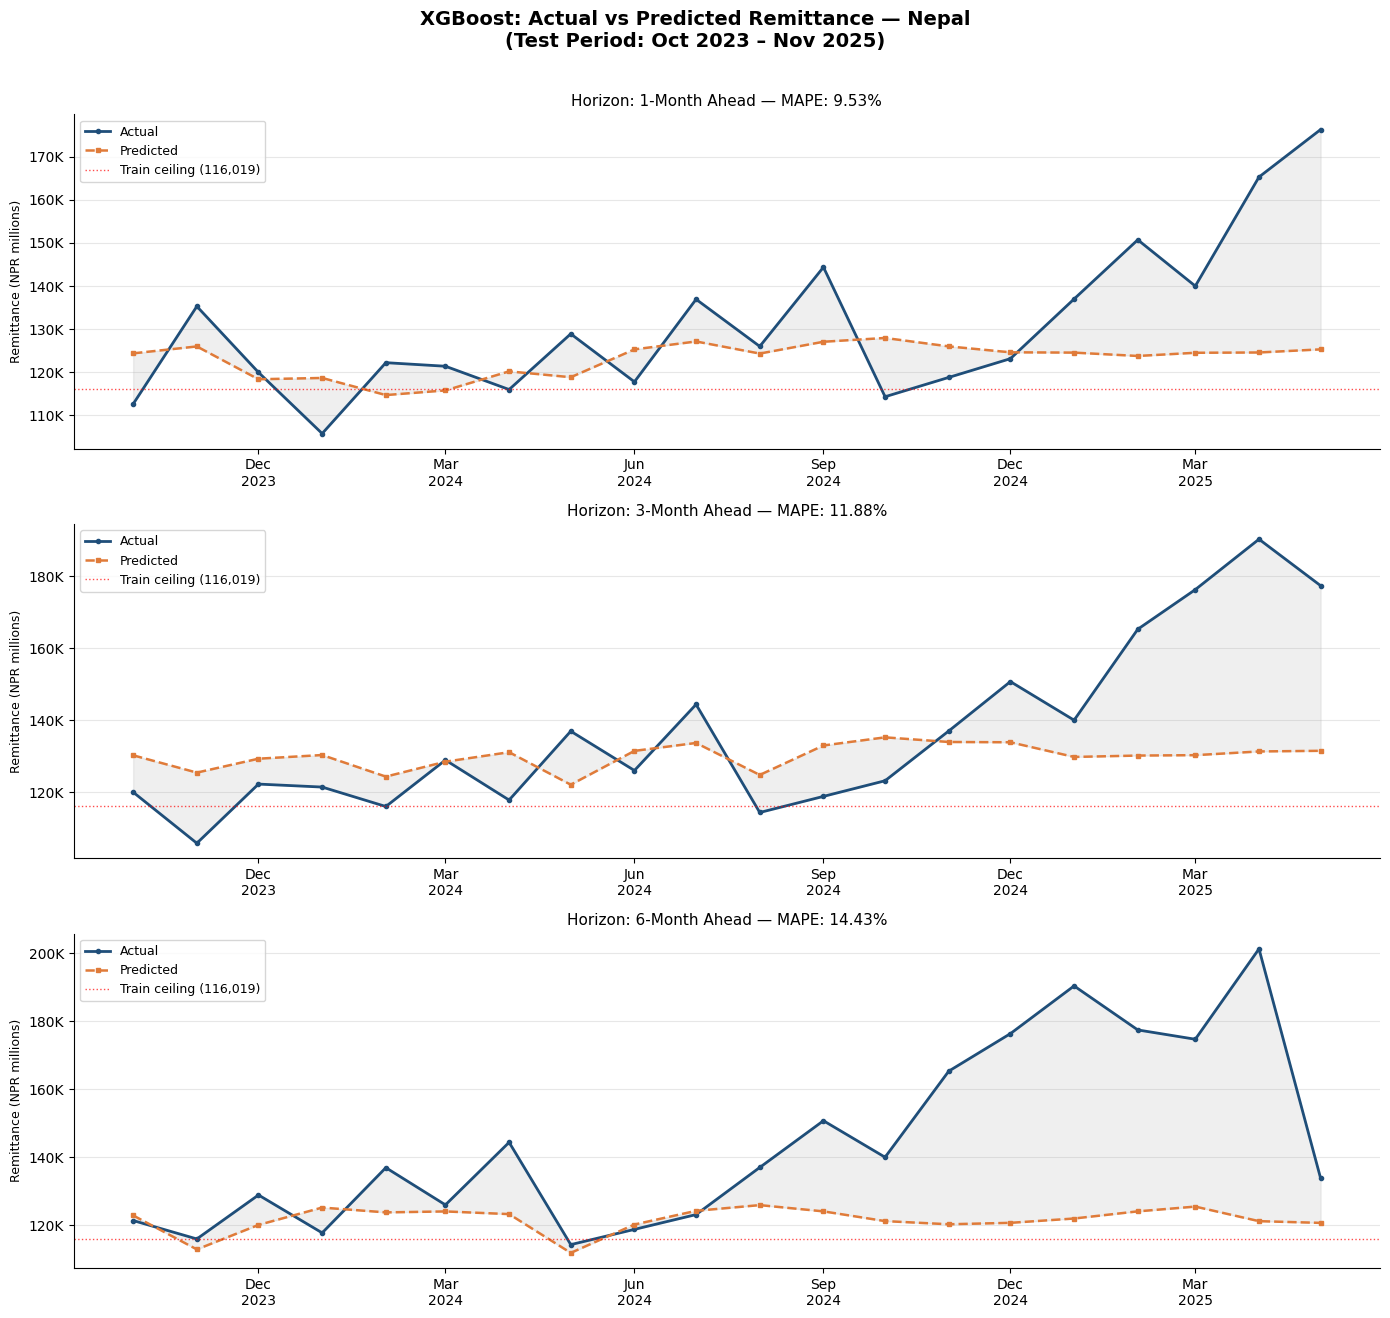

In [8]:
horizon_labels = {'target_1m': '1-Month Ahead', 'target_3m': '3-Month Ahead', 'target_6m': '6-Month Ahead'}

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)
fig.suptitle('XGBoost: Actual vs Predicted Remittance — Nepal\n(Test Period: Oct 2023 – Nov 2025)',
             fontsize=14, fontweight='bold', y=1.01)

colors = {'actual': '#1f4e79', 'predicted': '#e07b39'}

for ax, target_col in zip(axes, TARGETS):
    y_true = test[target_col]
    y_pred = predictions[target_col]
    mape_v = mape(y_true.values, y_pred)
    
    # The actual values correspond to dates shifted by the horizon
    # i.e. for target_1m, each test row's actual target is 1 month ahead
    # We plot against the test index for simplicity (date of observation)
    ax.plot(test.index, y_true.values,
            color=colors['actual'],    linewidth=2.0, label='Actual',    marker='o', markersize=3)
    ax.plot(test.index, y_pred,
            color=colors['predicted'], linewidth=1.8, label='Predicted', marker='s', markersize=3,
            linestyle='--')
    
    # Shade the gap between actual and predicted
    ax.fill_between(test.index, y_true.values, y_pred, alpha=0.12, color='gray')
    
    # Training ceiling reference line
    ax.axhline(y=train_ceiling, color='red', linewidth=1.0, linestyle=':', alpha=0.7,
               label=f'Train ceiling ({train_ceiling:,.0f})')
    
    ax.set_title(f"Horizon: {horizon_labels[target_col]} — MAPE: {mape_v:.2f}%", fontsize=11)
    ax.set_ylabel('Remittance (NPR millions)', fontsize=9)
    ax.legend(fontsize=9, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance (Gain)

XGBoost tracks how much each feature contributes to reducing prediction error across all splits in the ensemble — this is the **gain** importance metric. Features with higher gain are more informative for the model. We normalise gain to percentages for interpretability and plot separately for each forecasting horizon, since feature relevance may shift as the horizon extends.

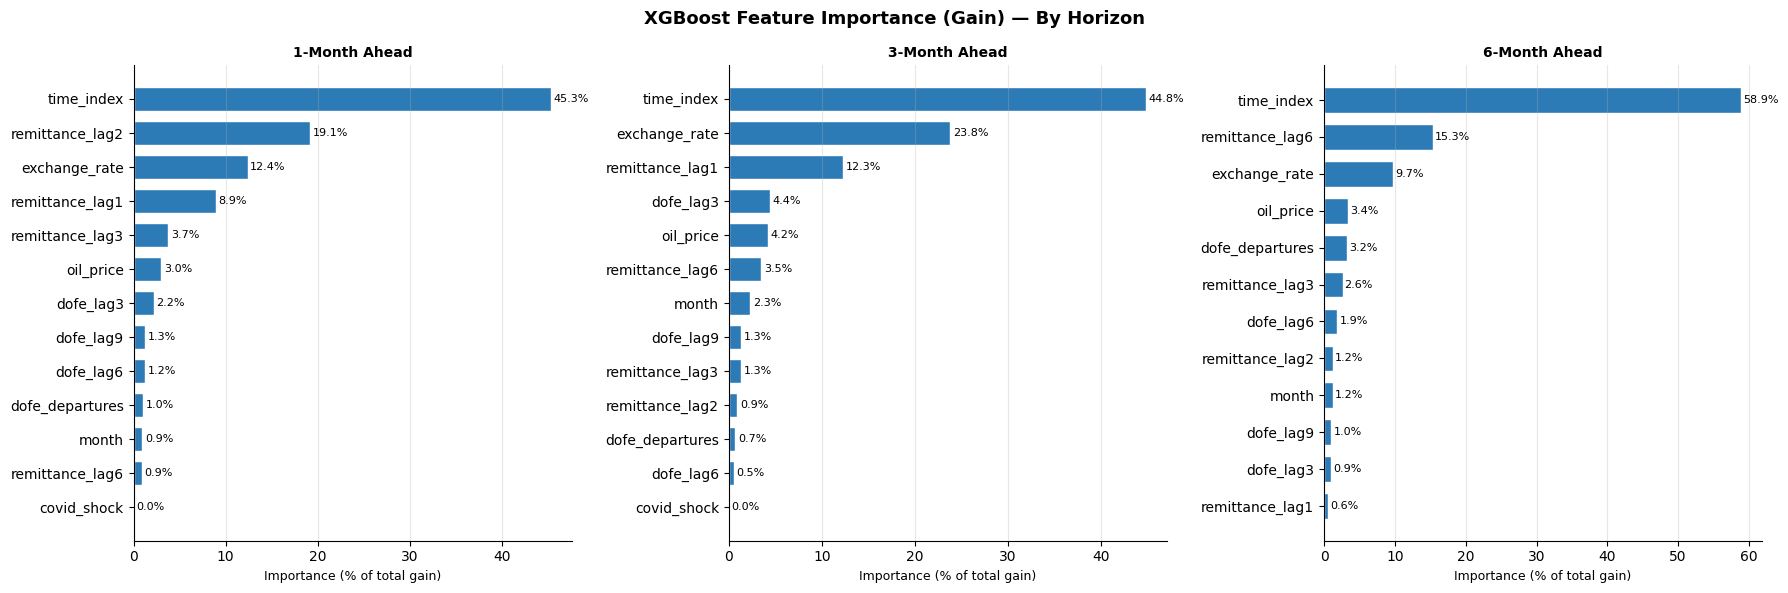

Chart saved as 'xgboost_feature_importance.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('XGBoost Feature Importance (Gain) — By Horizon', fontsize=13, fontweight='bold')

for ax, target_col in zip(axes, TARGETS):
    model = models[target_col]
    
    # Get importance scores
    importance = model.get_booster().get_score(importance_type='gain')
    imp_df = pd.DataFrame(importance.items(), columns=['Feature', 'Gain'])
    imp_df = imp_df.sort_values('Gain', ascending=True)
    
    # Normalise to 0–100 for easier reading
    imp_df['Gain_pct'] = imp_df['Gain'] / imp_df['Gain'].sum() * 100
    
    # Plot horizontal bar chart
    bars = ax.barh(imp_df['Feature'], imp_df['Gain_pct'],
                   color='#2c7bb6', edgecolor='white', height=0.7)
    
    # Add value labels
    for bar, val in zip(bars, imp_df['Gain_pct']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    
    horizon_label = horizon_labels[target_col]
    ax.set_title(f'{horizon_label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Importance (% of total gain)', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("Chart saved as 'xgboost_feature_importance.png'")

## 10. SHAP Analysis

Feature importance (gain) tells us which features the model uses most overall, but not *how* they influence individual predictions. **SHAP (SHapley Additive exPlanations)** values fill this gap — they decompose each prediction into the additive contribution of each feature, grounded in cooperative game theory.

A positive SHAP value pushes the prediction higher; a negative value pushes it lower. The bar plot shows mean absolute SHAP values across all test observations, giving a model-level view of feature influence per horizon.

=== SHAP ANALYSIS ===



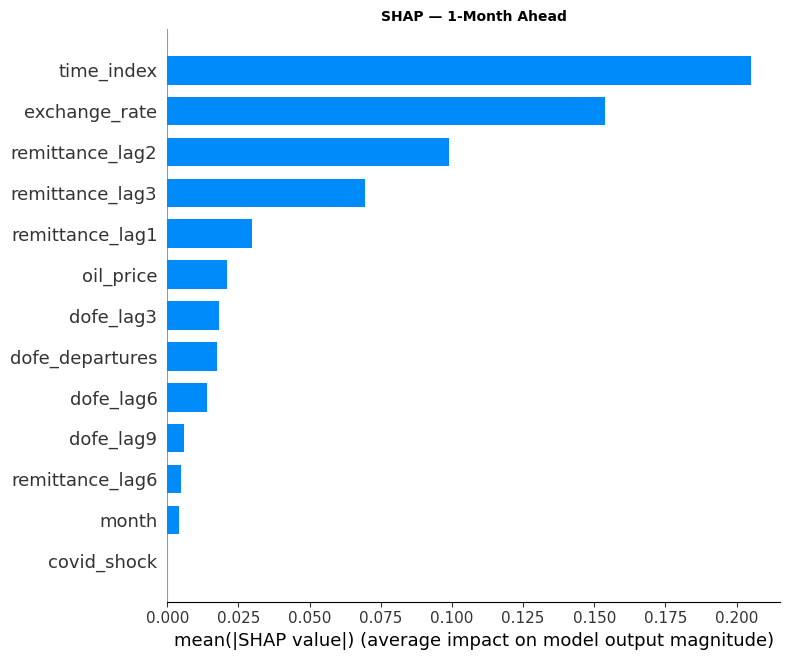

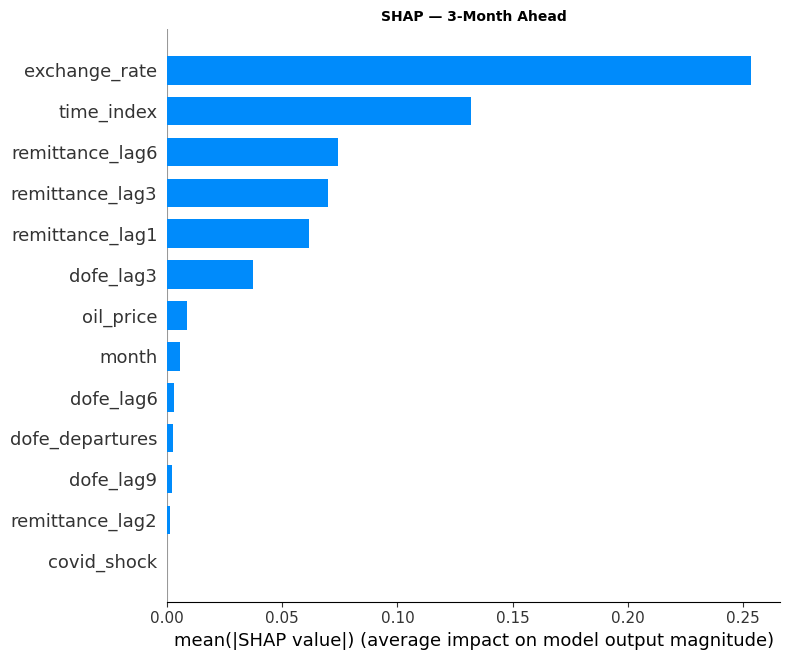

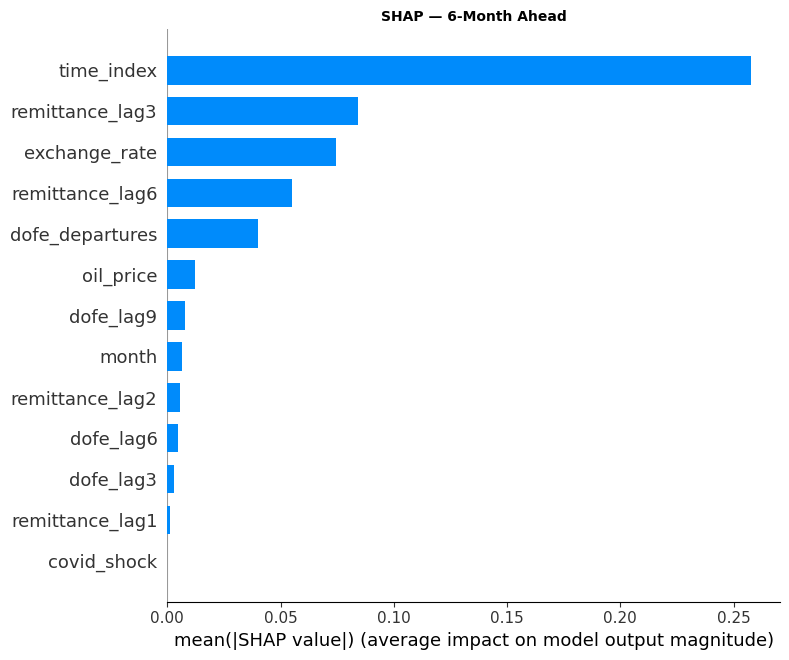

 SHAP analysis complete!


In [10]:

import shap

print("=== SHAP ANALYSIS ===\n")

for i, target_col in enumerate(TARGETS):
    explainer = shap.TreeExplainer(models[target_col])
    shap_values = explainer.shap_values(X_test)
    
    plt.figure(figsize=(8, 6))
    shap.summary_plot(
        shap_values,
        X_test,
        feature_names=FEATURES,
        show=False,
        plot_type='bar'
    )
    plt.title(f'SHAP — {horizon_labels[target_col]}', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(" SHAP analysis complete!")

## 11. Extrapolation Analysis

XGBoost is a tree-based model — it partitions the feature space using splits learned from training data. This means it **cannot extrapolate** beyond the range of values it was trained on. When test remittance values exceed the training maximum (the "ceiling"), the model is forced to predict within its learned range, producing systematically underestimated forecasts.

This section quantifies the severity of this limitation by identifying how many test months had actual remittance values above the training ceiling, and by how much.

In [11]:
print("EXTRAPOLATION ANALYSIS")
print("=" * 55)
print(f"Training remittance ceiling: {train_ceiling:>12,.0f}")
print(f"Test set max remittance:     {test_max:>12,.0f}")
print(f"Test months above ceiling:   {exceed_count:>3} of {len(test)} ({exceed_count/len(test)*100:.0f}%)")
print()
print("Months where actual remittance exceeded training ceiling:")
exceeded = test[test['remittance'] > train_ceiling][['remittance']].copy()
exceeded['pct_above_ceiling'] = ((exceeded['remittance'] - train_ceiling) / train_ceiling * 100).round(1)
exceeded.index = exceeded.index.strftime('%b %Y')
exceeded.columns = ['Actual Remittance', '% Above Ceiling']
print(exceeded.to_string())

EXTRAPOLATION ANALYSIS
Training remittance ceiling:      116,019
Test set max remittance:          165,300
Test months above ceiling:    16 of 20 (80%)

Months where actual remittance exceeded training ceiling:
          Actual Remittance  % Above Ceiling
date                                        
Oct 2023      136967.940946             18.1
Dec 2023      135289.001849             16.6
Jan 2024      119971.048636              3.4
Mar 2024      122222.088637              5.3
Apr 2024      121393.301193              4.6
Jun 2024      128905.097446             11.1
Jul 2024      117776.272322              1.5
Aug 2024      136930.000000             18.0
Sep 2024      126000.000000              8.6
Oct 2024      144380.000000             24.4
Dec 2024      118800.000000              2.4
Jan 2025      123150.000000              6.1
Feb 2025      137000.000000             18.1
Mar 2025      150730.000000             29.9
Apr 2025      140000.000000             20.7
May 2025      165300.000

## 12. Visualisation — Full Series with Train / Calibration / Test Split

This plot shows the full remittance time series with the three data splits clearly marked. The red dashed line is the training ceiling. Any actual values in the orange (test) region that exceed this line represent the extrapolation zone where XGBoost's predictions will be structurally limited.

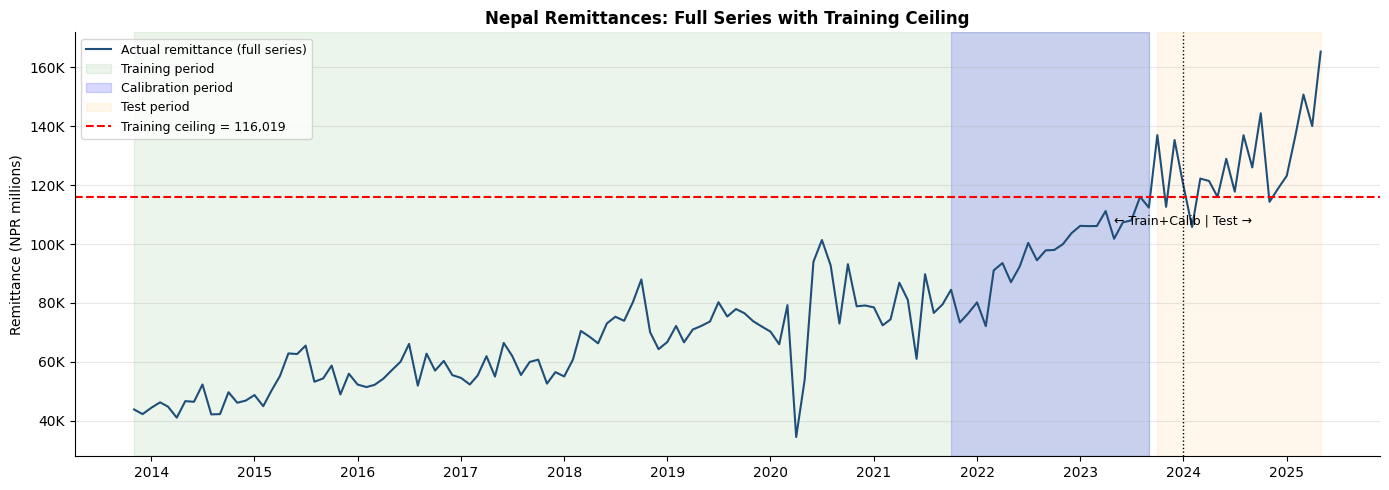

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
# Full time series
ax.plot(df_model.index, df_model['remittance'],
        color='#1f4e79', linewidth=1.5, label='Actual remittance (full series)')
# Training period shading
ax.axvspan(train_full.index.min(), train_full.index.max(), alpha=0.08, color='green', label='Training period')
# Calibration period shading
ax.axvspan(cal_set.index.min(), cal_set.index.max(), alpha=0.15, color='blue', label='Calibration period')
# Test period shading
ax.axvspan(test.index.min(), test.index.max(), alpha=0.08, color='orange', label='Test period')
# Training ceiling line
ax.axhline(y=train_ceiling, color='red', linewidth=1.5, linestyle='--',
           label=f'Training ceiling = {train_ceiling:,.0f}')
# Train/test boundary
ax.axvline(x=pd.Timestamp('2024-01-01'), color='black', linewidth=1, linestyle=':')
ax.text(pd.Timestamp('2024-01-01'), train_ceiling * 0.92, '← Train+Calib | Test →',
        fontsize=9, ha='center', color='black')
ax.set_title('Nepal Remittances: Full Series with Training Ceiling', fontsize=12, fontweight='bold')
ax.set_ylabel('Remittance (NPR millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Final Results Summary and Benchmark Comparison

We consolidate all evaluation metrics into a single results table and compare against published benchmarks. The primary comparison is MAPE against Ghimire (2026), who applied XGBoost to Nepal remittance forecasting over a similar feature set but an earlier and less volatile test period (2018–2023). The higher MAPE values in our results are expected given the post-COVID structural break and the extrapolation problem documented in Section 11.

In [13]:
# ── Full results summary ───────────────────────────────────────────────────────
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)
print(results_df.to_string())
print()
print("BENCHMARK COMPARISON (MAPE %)")
print("-" * 50)

comparison = pd.DataFrame([
    {'Model': 'Ghimire (2026) XGBoost',    'Test Period': '2018–2023',         'MAPE (%)': 5.90,  'Note': 'Reference'},
    {'Model': 'Our XGBoost (1m ahead)',     'Test Period': 'Oct 2023–Nov 2025', 'MAPE (%)': round(mape(test['target_1m'].values, predictions['target_1m']), 2), 'Note': 'Extrapolation issue'},
    {'Model': 'Our XGBoost (3m ahead)',     'Test Period': 'Oct 2023–Nov 2025', 'MAPE (%)': round(mape(test['target_3m'].values, predictions['target_3m']), 2), 'Note': 'Extrapolation issue'},
    {'Model': 'Our XGBoost (6m ahead)',     'Test Period': 'Oct 2023–Nov 2025', 'MAPE (%)': round(mape(test['target_6m'].values, predictions['target_6m']), 2), 'Note': 'Extrapolation issue'},
]).set_index('Model')

print(comparison.to_string())


FINAL MODEL PERFORMANCE SUMMARY
            RMSE      MAE  MAPE (%)  Coverage (%)  Winkler Score
Horizon                                                         
1M       18270.5  13408.1      9.53         100.0       110885.5
3M       23493.3  17601.5     11.88         100.0       124110.4
6M       34337.1  24146.7     14.43          90.0       148362.5

BENCHMARK COMPARISON (MAPE %)
--------------------------------------------------
                              Test Period  MAPE (%)                 Note
Model                                                                   
Ghimire (2026) XGBoost          2018–2023      5.90            Reference
Our XGBoost (1m ahead)  Oct 2023–Nov 2025      9.53  Extrapolation issue
Our XGBoost (3m ahead)  Oct 2023–Nov 2025     11.88  Extrapolation issue
Our XGBoost (6m ahead)  Oct 2023–Nov 2025     14.43  Extrapolation issue


In [14]:
import os
os.makedirs("output", exist_ok=True)

# Save XGBoost predictions and actuals for each horizon
np.save("output/xgb_pred_1m.npy", predictions['target_1m'])
np.save("output/xgb_true_1m.npy", test['target_1m'].values)

np.save("output/xgb_pred_3m.npy", predictions['target_3m'])
np.save("output/xgb_true_3m.npy", test['target_3m'].values)

np.save("output/xgb_pred_6m.npy", predictions['target_6m'])
np.save("output/xgb_true_6m.npy", test['target_6m'].values)

print("Saved all XGBoost predictions to output/")

Saved all XGBoost predictions to output/
